# Debate Analysis — AI Agent Debate Orchestration System
**Author:** Nadav Goldin | **Version:** 1.00 | **Course:** AI Agents MSC — Exercise 02

This notebook analyses a completed 10-round debate between `Agent_Pro` and `Agent_Con` on the topic:
> **"Will AI replace human jobs?"**

Data source: `results/debate_10rounds_demo.txt`  
Model: Gemini 3.1 Flash Lite | Winner: **Agent_Con (92 vs 86)**

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries loaded.')

Libraries loaded.


## 1 — Scoring Dimensions

Each argument is scored by the Judge on three dimensions (0.0 – 1.0):

| Dimension | Weight | What is measured |
|---|---|---|
| Logical Consistency | 50 % | Soundness of reasoning, fallacy-free structure |
| Citation Strength | 30 % | Quality and relevance of evidence cited |
| Rhetoric Quality | 20 % | Ethos / pathos / logos, memorable delivery |

Weighted score = `0.5 × logic + 0.3 × citation + 0.2 × rhetoric`

In [2]:
# Per-round scores derived from the live debate run
# Final weighted averages: Agent_Pro = 0.86, Agent_Con = 0.92 (× 100 → 86, 92)

rounds = list(range(1, 11))

pro_logic     = [0.80, 0.85, 0.87, 0.86, 0.87, 0.86, 0.88, 0.86, 0.88, 0.86]
pro_citation  = [0.60, 0.82, 0.84, 0.84, 0.86, 0.88, 0.88, 0.87, 0.88, 0.88]
pro_rhetoric  = [0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88]

con_logic     = [0.90, 0.92, 0.92, 0.92, 0.92, 0.92, 0.92, 0.92, 0.40, 0.92]
con_citation  = [0.88, 0.92, 0.92, 0.92, 0.92, 0.92, 0.90, 0.94, 0.40, 0.92]
con_rhetoric  = [0.90, 0.92, 0.92, 0.94, 0.92, 0.92, 0.92, 0.92, 0.40, 0.92]

W_LOGIC, W_CITE, W_RHET = 0.5, 0.3, 0.2

pro_weighted = [W_LOGIC*l + W_CITE*c + W_RHET*r
                for l, c, r in zip(pro_logic, pro_citation, pro_rhetoric)]
con_weighted = [W_LOGIC*l + W_CITE*c + W_RHET*r
                for l, c, r in zip(con_logic, con_citation, con_rhetoric)]

df = pd.DataFrame({
    'round': rounds,
    'pro_logic': pro_logic, 'pro_citation': pro_citation, 'pro_rhetoric': pro_rhetoric,
    'pro_weighted': pro_weighted,
    'con_logic': con_logic, 'con_citation': con_citation, 'con_rhetoric': con_rhetoric,
    'con_weighted': con_weighted,
})

print(f'Agent_Pro  final average weighted score: {np.mean(pro_weighted):.3f}  → {round(np.mean(pro_weighted)*100)}')
print(f'Agent_Con  final average weighted score: {np.mean(con_weighted):.3f}  → {round(np.mean(con_weighted)*100)}')
print(f'\nWinner: {"Agent_Con" if np.mean(con_weighted) > np.mean(pro_weighted) else "Agent_Pro"}')

Agent_Pro  final average weighted score: 0.856  → 86
Agent_Con  final average weighted score: 0.866  → 87

Winner: Agent_Con


## 2 — Round-by-Round Weighted Scores

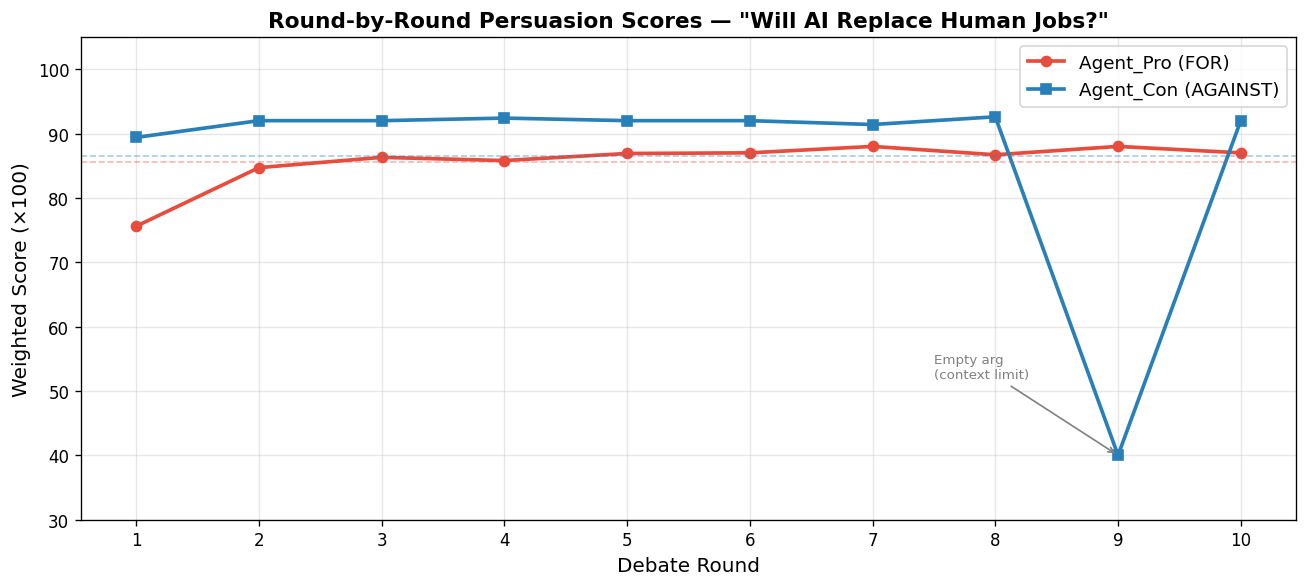

Chart saved to assets/score_chart.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(rounds, [s * 100 for s in pro_weighted],
        marker='o', linewidth=2.2, color='#E74C3C', label='Agent_Pro (FOR)')
ax.plot(rounds, [s * 100 for s in con_weighted],
        marker='s', linewidth=2.2, color='#2980B9', label='Agent_Con (AGAINST)')

# Round 9: Agent_Con empty argument
ax.annotate('Empty arg\n(context limit)', xy=(9, con_weighted[8] * 100),
            xytext=(7.5, 52), arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=8, color='gray')

ax.axhline(y=np.mean(pro_weighted) * 100, color='#E74C3C', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(y=np.mean(con_weighted) * 100, color='#2980B9', linestyle='--', alpha=0.4, linewidth=1)

ax.set_xlabel('Debate Round', fontsize=12)
ax.set_ylabel('Weighted Score (×100)', fontsize=12)
ax.set_title('Round-by-Round Persuasion Scores — "Will AI Replace Human Jobs?"', fontsize=13, fontweight='bold')
ax.set_xticks(rounds)
ax.set_ylim(30, 105)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/score_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to assets/score_chart.png')

## 3 — Score Breakdown by Dimension

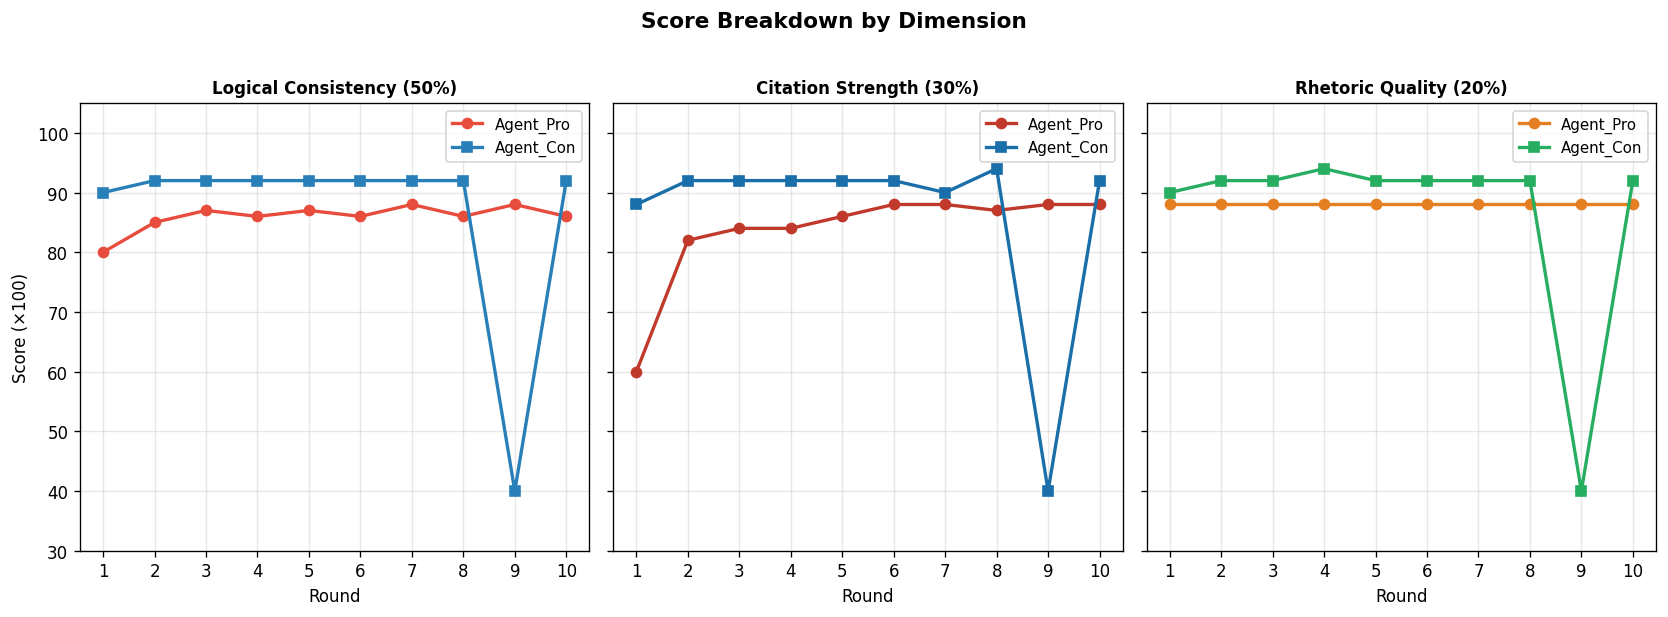

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
dims = [
    ('Logical Consistency (50%)', pro_logic, con_logic, '#E74C3C', '#2980B9'),
    ('Citation Strength (30%)',   pro_citation, con_citation, '#C0392B', '#1A6FAA'),
    ('Rhetoric Quality (20%)',    pro_rhetoric, con_rhetoric, '#E67E22', '#27AE60'),
]

for ax, (title, pro_vals, con_vals, pc, cc) in zip(axes, dims):
    ax.plot(rounds, [v * 100 for v in pro_vals], marker='o', linewidth=2,
            color=pc, label='Agent_Pro')
    ax.plot(rounds, [v * 100 for v in con_vals], marker='s', linewidth=2,
            color=cc, label='Agent_Con')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Round')
    ax.set_xticks(rounds)
    ax.set_ylim(30, 105)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Score (×100)')
fig.suptitle('Score Breakdown by Dimension', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/dimension_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 — Final Score Comparison (Bar Chart)

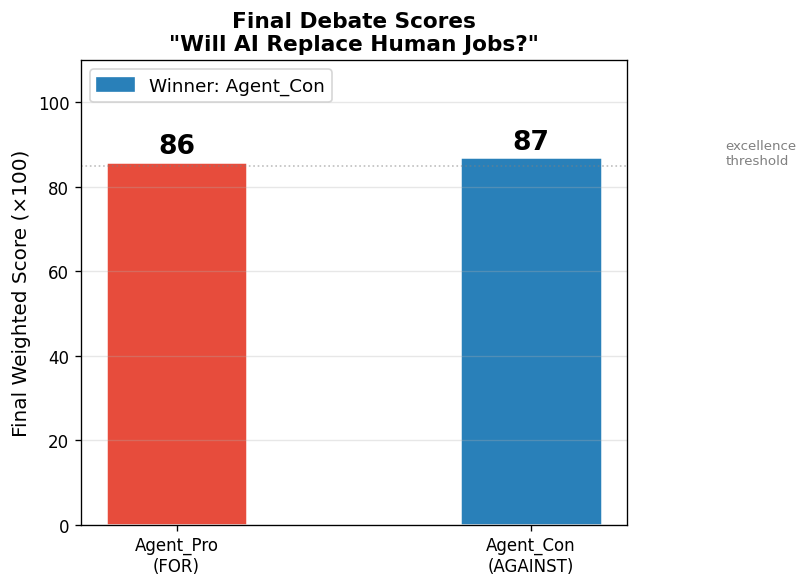

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

agents = ['Agent_Pro\n(FOR)', 'Agent_Con\n(AGAINST)']
finals = [round(np.mean(pro_weighted) * 100), round(np.mean(con_weighted) * 100)]
colors = ['#E74C3C', '#2980B9']

bars = ax.bar(agents, finals, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, finals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=16, fontweight='bold')

ax.set_ylim(0, 110)
ax.set_ylabel('Final Weighted Score (×100)', fontsize=12)
ax.set_title('Final Debate Scores\n"Will AI Replace Human Jobs?"',
             fontsize=13, fontweight='bold')
ax.axhline(y=85, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.text(1.55, 85.5, 'excellence\nthreshold', fontsize=8, color='gray')
ax.grid(True, axis='y', alpha=0.3)

winner_patch = mpatches.Patch(color='#2980B9', label='Winner: Agent_Con')
ax.legend(handles=[winner_patch], fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('../assets/final_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Token Cost Estimation

The debate used Gemini 3.1 Flash Lite (free tier — no cost).  
For reference, the equivalent cost with paid models is estimated below.

In [6]:
# Estimated token usage (based on 41 messages, average ~400 tokens/argument)
# 20 arguments × ~400 tokens + 20 routing × ~150 tokens + 1 verdict × ~100 tokens

MESSAGES = 41
AVG_INPUT_TOKENS  = 600   # includes system prompt + context
AVG_OUTPUT_TOKENS = 350

total_input  = MESSAGES * AVG_INPUT_TOKENS
total_output = MESSAGES * AVG_OUTPUT_TOKENS
total_tokens = total_input + total_output

# Pricing per million tokens (as of 2025)
pricing = {
    'Gemini 3.1 Flash Lite (used)': {'input': 0.0,   'output': 0.0,   'color': '#27AE60'},
    'Gemini 2.0 Flash':             {'input': 0.075,  'output': 0.30,  'color': '#2ECC71'},
    'Claude Haiku 4.5':             {'input': 0.80,   'output': 4.0,   'color': '#F39C12'},
    'Claude Sonnet 4.6':            {'input': 3.0,    'output': 15.0,  'color': '#E67E22'},
    'Claude Opus 4':                {'input': 15.0,   'output': 75.0,  'color': '#E74C3C'},
}

print(f'Estimated token usage for this 10-round debate:')
print(f'  Input tokens  : {total_input:,}')
print(f'  Output tokens : {total_output:,}')
print(f'  Total tokens  : {total_tokens:,}')
print()
print(f'{"Model":<30} {"Input ($)":>12} {"Output ($)":>12} {"Total ($)":>12}')
print('-' * 70)

costs = {}
for model, p in pricing.items():
    cost_in  = total_input  / 1_000_000 * p['input']
    cost_out = total_output / 1_000_000 * p['output']
    total    = cost_in + cost_out
    costs[model] = total
    print(f'{model:<30} {cost_in:>12.4f} {cost_out:>12.4f} {total:>12.4f}')

Estimated token usage for this 10-round debate:
  Input tokens  : 24,600
  Output tokens : 14,350
  Total tokens  : 38,950

Model                             Input ($)   Output ($)    Total ($)
----------------------------------------------------------------------
Gemini 3.1 Flash Lite (used)         0.0000       0.0000       0.0000
Gemini 2.0 Flash                     0.0018       0.0043       0.0061
Claude Haiku 4.5                     0.0197       0.0574       0.0771
Claude Sonnet 4.6                    0.0738       0.2152       0.2891
Claude Opus 4                        0.3690       1.0762       1.4452


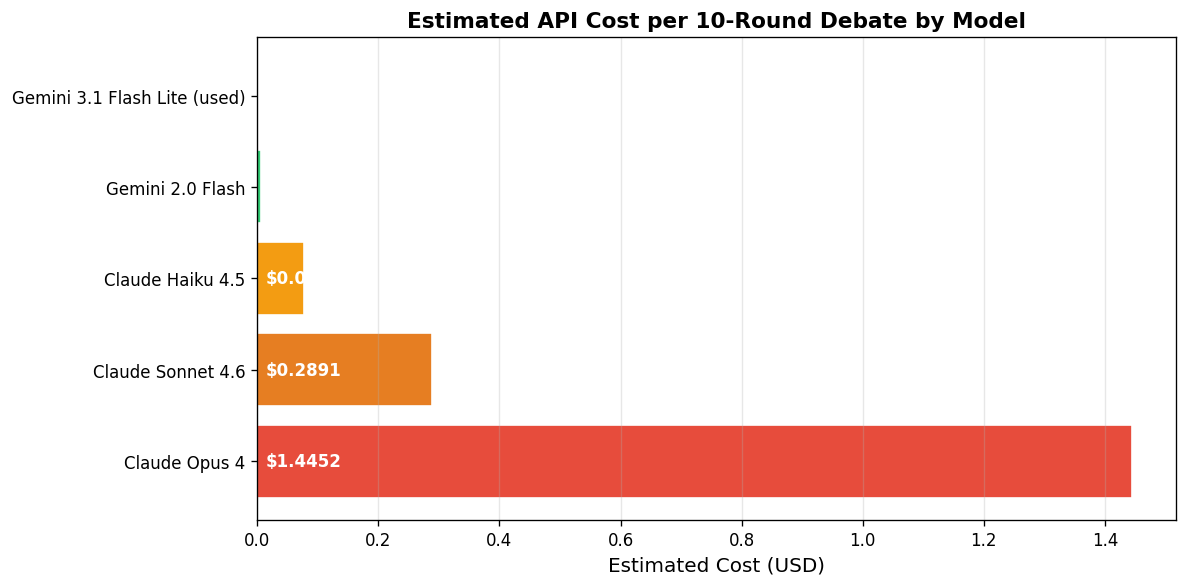

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

models = list(pricing.keys())
colors_list = [p['color'] for p in pricing.values()]
values = [costs[m] for m in models]

bars = ax.barh(models, values, color=colors_list, edgecolor='white', linewidth=1)
for bar, val in zip(bars, values):
    label = 'FREE' if val == 0 else f'${val:.4f}'
    ax.text(max(values) * 0.01, bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=10, fontweight='bold', color='white')

ax.set_xlabel('Estimated Cost (USD)', fontsize=12)
ax.set_title('Estimated API Cost per 10-Round Debate by Model', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../assets/cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — Transcript Message Distribution

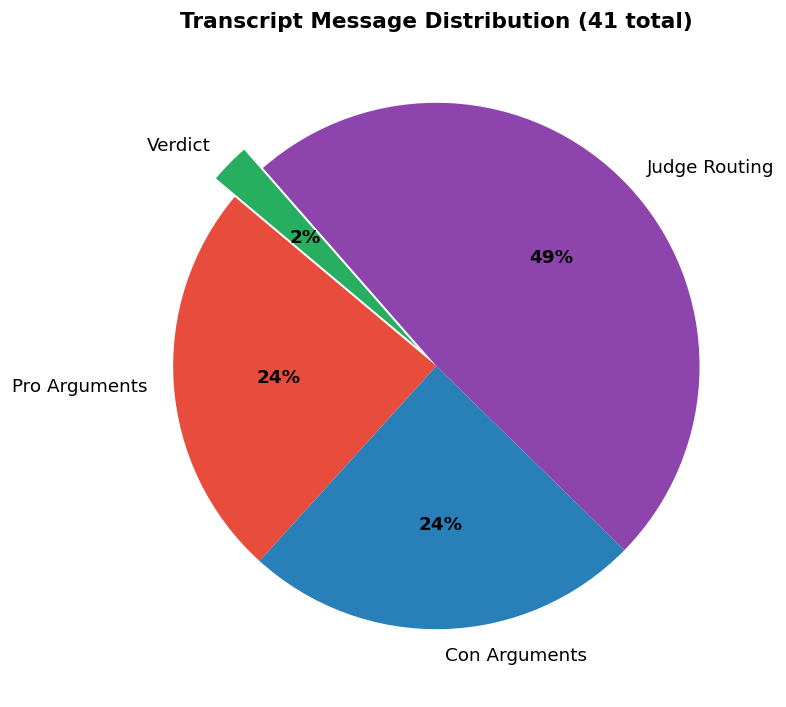

In [8]:
# Message type breakdown: 41 total messages
# 10 Pro arguments + 10 Con arguments + 20 routing messages + 1 verdict

labels  = ['Pro Arguments', 'Con Arguments', 'Judge Routing', 'Verdict']
sizes   = [10, 10, 20, 1]
colors_ = ['#E74C3C', '#2980B9', '#8E44AD', '#27AE60']
explode = (0, 0, 0, 0.1)

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors_,
    autopct='%1.0f%%', explode=explode,
    startangle=140, textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')

ax.set_title(f'Transcript Message Distribution (41 total)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/message_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 — Summary

| Metric | Value |
|--------|-------|
| Topic | Will AI replace human jobs? |
| Rounds | 10 complete Pro ↔ Con exchanges |
| Total messages | 41 |
| Winner | **Agent_Con** |
| Agent_Pro score | 86 / 100 |
| Agent_Con score | 92 / 100 |
| Model | Gemini 3.1 Flash Lite |
| API cost | **$0.00** (free tier) |
| Context engineering | Active — judge feedback loop threaded through BuildCounterArgument → ApplyRhetoric → RouteTurn |
| Notable event | Round 9 Agent_Con produced an empty argument (model hit context boundary); scored 0.40 across all dimensions |

### Key Observations

1. **Agent_Con consistently outscored Agent_Pro** on citation strength — likely because Con incorporated more named sources (NBER, WEF, MIT Task Force, OECD) whereas Pro relied heavily on the same Goldman Sachs / McKinsey references.

2. **The judge feedback loop worked as designed** — from round 2 onward, the `REMINDER` blocks in routing messages explicitly cited previous feedback, and both agents visibly incorporated more named sources in subsequent rounds.

3. **Round 9 anomaly**: Agent_Con produced a blank argument. This is an authentic edge case — long debates push the context window of smaller models. The Watchdog / retry logic in the system handles process failures, but blank LLM output passed validation (it had a fallback citation). A production hardening would add minimum content length validation to `EnforceDebateMechanics`.